<a href="https://colab.research.google.com/github/boodscode237/nlp_with_python/blob/main/Learning_to_Classify_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1   Supervised Classification

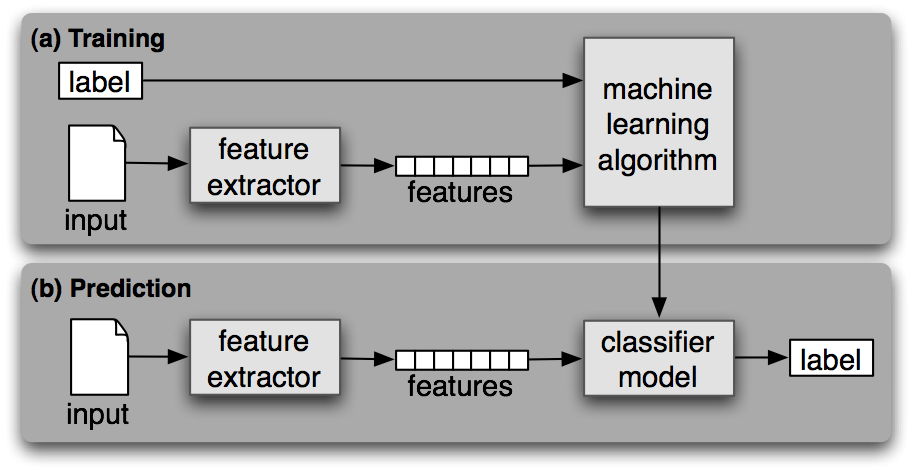

### 1.1   Gender Identification

In [ ]:
def gender_features(word):
    features = {
        'last_letter': word[-1],
        'first_letter': word[0],
        'name_length': len(word),
        'first_two_letters': word[:2],
        'last_two_letters': word[-2:],
        'has_vowel': any(letter in 'aeiouAEIOU' for letter in word)
    }
    return features
gender_features('Shrek')

{'last_letter': 'k',
 'first_letter': 'S',
 'name_length': 5,
 'first_two_letters': 'Sh',
 'last_two_letters': 'ek',
 'has_vowel': True}

In [ ]:
import nltk
nltk.download('names')

[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Unzipping corpora/names.zip.


True

In [ ]:
from nltk.corpus import names
labeled_names = ([(name, 'male') for name in names.words('male.txt')] +
 [(name, 'female') for name in names.words('female.txt')])

In [ ]:
import random
random.shuffle(labeled_names)

In [ ]:
labeled_names[0]

('Reed', 'male')

In [ ]:
featuresets = [(gender_features(n), gender) for (n, gender) in labeled_names]
train_set, test_set = featuresets[500:], featuresets[:500]
classifier = nltk.NaiveBayesClassifier.train(train_set)

In [ ]:
featuresets[1:3]

[({'last_letter': 's',
   'first_letter': 'O',
   'name_length': 8,
   'first_two_letters': 'Od',
   'last_two_letters': 'us',
   'has_vowel': True},
  'male'),
 ({'last_letter': 'm',
   'first_letter': 'S',
   'name_length': 6,
   'first_two_letters': 'Sh',
   'last_two_letters': 'om',
   'has_vowel': True},
  'male')]

In [ ]:
classifier

In [ ]:
classifier.classify(gender_features('Neo'))

'male'

In [ ]:
classifier.classify(gender_features('Trinity'))

'female'

In [ ]:
classifier.classify(gender_features('Tristian'))

'male'

In [ ]:
display(nltk.classify.accuracy(classifier, test_set))

0.8

In [ ]:
classifier.show_most_informative_features(5)

Most Informative Features
        last_two_letters = 'na'           female : male   =     99.4 : 1.0
        last_two_letters = 'la'           female : male   =     75.4 : 1.0
        last_two_letters = 'ia'           female : male   =     55.3 : 1.0
        last_two_letters = 'sa'           female : male   =     36.0 : 1.0
             last_letter = 'a'            female : male   =     34.3 : 1.0


In [ ]:
from nltk.classify import apply_features
train_set = apply_features(gender_features, labeled_names[500:])
test_set = apply_features(gender_features, labeled_names[:500])

In [ ]:
classifier = nltk.NaiveBayesClassifier.train(train_set)

In [ ]:
display(nltk.classify.accuracy(classifier, test_set))

0.8

### 1.2   Choosing The Right Features

In [ ]:
def gender_features2(name):
    features = {}
    features["first_letter"] = name[0].lower()
    features["last_letter"] = name[-1].lower()
    for letter in 'abcdefghijklmnopqrstuvwxyz':
        features["count({})".format(letter)] = name.lower().count(letter)
        features["has({})".format(letter)] = (letter in name.lower())
    return features

In [ ]:
gender_features2('John')

{'first_letter': 'j',
 'last_letter': 'n',
 'count(a)': 0,
 'has(a)': False,
 'count(b)': 0,
 'has(b)': False,
 'count(c)': 0,
 'has(c)': False,
 'count(d)': 0,
 'has(d)': False,
 'count(e)': 0,
 'has(e)': False,
 'count(f)': 0,
 'has(f)': False,
 'count(g)': 0,
 'has(g)': False,
 'count(h)': 1,
 'has(h)': True,
 'count(i)': 0,
 'has(i)': False,
 'count(j)': 1,
 'has(j)': True,
 'count(k)': 0,
 'has(k)': False,
 'count(l)': 0,
 'has(l)': False,
 'count(m)': 0,
 'has(m)': False,
 'count(n)': 1,
 'has(n)': True,
 'count(o)': 1,
 'has(o)': True,
 'count(p)': 0,
 'has(p)': False,
 'count(q)': 0,
 'has(q)': False,
 'count(r)': 0,
 'has(r)': False,
 'count(s)': 0,
 'has(s)': False,
 'count(t)': 0,
 'has(t)': False,
 'count(u)': 0,
 'has(u)': False,
 'count(v)': 0,
 'has(v)': False,
 'count(w)': 0,
 'has(w)': False,
 'count(x)': 0,
 'has(x)': False,
 'count(y)': 0,
 'has(y)': False,
 'count(z)': 0,
 'has(z)': False}

In [ ]:
featuresets = [(gender_features2(n), gender) for (n, gender) in labeled_names]
train_set, test_set = featuresets[500:], featuresets[:500]
classifier = nltk.NaiveBayesClassifier.train(train_set)
print(nltk.classify.accuracy(classifier, test_set))

0.77


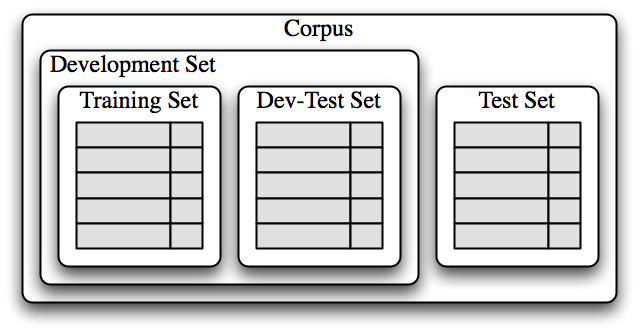

In [ ]:
train_names = labeled_names[1500:]
devtest_names = labeled_names[500:1500]
test_names = labeled_names[:500]

In [ ]:
train_set = [(gender_features(n), gender) for (n, gender) in train_names]
devtest_set = [(gender_features(n), gender) for (n, gender) in devtest_names]
test_set = [(gender_features(n), gender) for (n, gender) in test_names]
classifier = nltk.NaiveBayesClassifier.train(train_set)
print(nltk.classify.accuracy(classifier, devtest_set))

0.798


In [ ]:
errors = []
for (name, tag) in devtest_names:
    guess = classifier.classify(gender_features(name))
    if guess != tag:
        errors.append( (tag, guess, name) )

In [ ]:
for (tag, guess, name) in sorted(errors):
    print('correct={:<8} guess={:<8s} name={:<30}'.format(tag, guess, name))

correct=female   guess=male     name=Adey                          
correct=female   guess=male     name=Adriaens                      
correct=female   guess=male     name=Ag                            
correct=female   guess=male     name=Allsun                        
correct=female   guess=male     name=Ambur                         
correct=female   guess=male     name=Anett                         
correct=female   guess=male     name=Ashlen                        
correct=female   guess=male     name=Austin                        
correct=female   guess=male     name=Averil                        
correct=female   guess=male     name=Beitris                       
correct=female   guess=male     name=Bell                          
correct=female   guess=male     name=Bliss                         
correct=female   guess=male     name=Britaney                      
correct=female   guess=male     name=Cass                          
correct=female   guess=male     name=Chad       

In [ ]:
guess

'female'

In [ ]:
errors[:10]

[('male', 'female', 'Ruddie'),
 ('male', 'female', 'Karsten'),
 ('female', 'male', 'Sheelagh'),
 ('male', 'female', 'Merlin'),
 ('male', 'female', 'Che'),
 ('female', 'male', 'Salome'),
 ('female', 'male', 'Millisent'),
 ('male', 'female', 'Broddie'),
 ('male', 'female', 'Alexei'),
 ('male', 'female', 'Doyle')]

### 1.3   Document Classification

In [ ]:
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
random.shuffle(documents)

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


In [ ]:
all_words = nltk.FreqDist(w.lower() for w in movie_reviews.words())
word_features = list(all_words)[:2000]

def document_features(document):
    document_words = set(document)
    features = {}
    for word in word_features:
        features['contains({})'.format(word)] = (word in document_words)
    return features

In [ ]:
featuresets = [(document_features(d), c) for (d,c) in documents]
train_set, test_set = featuresets[100:], featuresets[:100]
classifier = nltk.NaiveBayesClassifier.train(train_set)

In [ ]:
print(nltk.classify.accuracy(classifier, test_set))

0.81


In [ ]:
classifier.show_most_informative_features(5)

Most Informative Features
   contains(outstanding) = True              pos : neg    =     13.6 : 1.0
         contains(damon) = True              pos : neg    =      7.5 : 1.0
        contains(seagal) = True              neg : pos    =      7.5 : 1.0
   contains(wonderfully) = True              pos : neg    =      6.5 : 1.0
          contains(lame) = True              neg : pos    =      5.8 : 1.0


### 1.4   Part-of-Speech Tagging

In [ ]:
nltk.download('brown')
from nltk.corpus import brown
suffix_fdist = nltk.FreqDist()
for word in brown.words():
    word = word.lower()
    suffix_fdist[word[-1:]] += 1
    suffix_fdist[word[-2:]] += 1
    suffix_fdist[word[-3:]] += 1

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


In [ ]:
common_suffixes = [suffix for (suffix, count) in suffix_fdist.most_common(100)]
print(common_suffixes)

['e', ',', '.', 's', 'd', 't', 'he', 'n', 'a', 'of', 'the', 'y', 'r', 'to', 'in', 'f', 'o', 'ed', 'nd', 'is', 'on', 'l', 'g', 'and', 'ng', 'er', 'as', 'ing', 'h', 'at', 'es', 'or', 're', 'it', '``', 'an', "''", 'm', ';', 'i', 'ly', 'ion', 'en', 'al', '?', 'nt', 'be', 'hat', 'st', 'his', 'th', 'll', 'le', 'ce', 'by', 'ts', 'me', 've', "'", 'se', 'ut', 'was', 'for', 'ent', 'ch', 'k', 'w', 'ld', '`', 'rs', 'ted', 'ere', 'her', 'ne', 'ns', 'ith', 'ad', 'ry', ')', '(', 'te', '--', 'ay', 'ty', 'ot', 'p', 'nce', "'s", 'ter', 'om', 'ss', ':', 'we', 'are', 'c', 'ers', 'uld', 'had', 'so', 'ey']


In [ ]:
def pos_features(word):
    features = {}
    for suffix in common_suffixes:
        features['endswith({})'.format(suffix)] = word.lower().endswith(suffix)
    return features

In [ ]:
tagged_words = brown.tagged_words(categories="news")
featuresets = [(pos_features(n), g) for (n,g) in tagged_words]

In [ ]:
size = int(len(featuresets) * 0.1)
train_set, test_set = featuresets[size:], featuresets[:size]

In [ ]:
classifier = nltk.DecisionTreeClassifier.train(train_set)
nltk.classify.accuracy(classifier, test_set)

0.6270512182993535

In [ ]:
classifier.classify(pos_features('cats'))

'NNS'

In [ ]:
print(classifier.pseudocode(depth=4))

if endswith(the) == False: 
  if endswith(,) == False: 
    if endswith(s) == False: 
      if endswith(.) == False: return '.'
      if endswith(.) == True: return '.'
    if endswith(s) == True: 
      if endswith(is) == False: return 'PP$'
      if endswith(is) == True: return 'BEZ'
  if endswith(,) == True: return ','
if endswith(the) == True: return 'AT'



In [ ]:
def classify_word_from_pseudocode(word):
    features = pos_features(word)

    if features['endswith(,)'] == True:
        return ','
    elif features['endswith(,)'] == False:
        if features['endswith(the)'] == True:
            return 'AT'
        elif features['endswith(the)'] == False:
            if features['endswith(s)'] == True:
                if features['endswith(is)'] == True:
                    return 'BEZ'
                elif features['endswith(is)'] == False:
                    return 'VBZ'
            elif features['endswith(s)'] == False:
                if features['endswith(.)'] == True:
                    return '.'
                elif features['endswith(.)'] == False:
                    return 'NN'
    return 'UNKNOWN'

print(f"'cats' classified as: {classify_word_from_pseudocode('cats')}")
print(f"'the' classified as: {classify_word_from_pseudocode('the')}")
print(f"'running' classified as: {classify_word_from_pseudocode('running')}")
print(f"'run' classified as: {classify_word_from_pseudocode('run')}")
print(f"',' classified as: {classify_word_from_pseudocode(',')}")


'cats' classified as: VBZ
'the' classified as: AT
'running' classified as: NN
'run' classified as: NN
',' classified as: ,


### 1.5   Exploiting Context

In [ ]:
def pos_features(sentence, i):
    features = {"suffix(1)": sentence[i][-1:],
                "suffix(2)": sentence[i][-2:],
                "suffix(3)": sentence[i][-3:]}
    if i == 0:
        features["prev-word"] = "<START>"
    else:
        features["prev-word"] = sentence[i-1]
    return features

In [ ]:
pos_features(brown.sents()[0], 8)

{'suffix(1)': 'n', 'suffix(2)': 'on', 'suffix(3)': 'ion', 'prev-word': 'an'}

In [ ]:
tagged_sents = brown.tagged_sents(categories='news')
featuresets = []
for tagged_sent in tagged_sents:
    untagged_sent = nltk.tag.untag(tagged_sent)
    for i, (word, tag) in enumerate(tagged_sent):
        featuresets.append( (pos_features(untagged_sent, i), tag) )

In [ ]:
size = int(len(featuresets) * 0.1)
train_set, test_set = featuresets[size:], featuresets[:size]
classifier = nltk.NaiveBayesClassifier.train(train_set)

In [ ]:
nltk.classify.accuracy(classifier, test_set)

0.7891596220785678

### 1.6   Sequence Classification

In [47]:
def pos_features(sentence, i, history):
    features = {"suffix(1)": sentence[i][-1:],
                "suffix(2)": sentence[i][-2:],
                "suffix(3)": sentence[i][-3:]}
    if i == 0:
        features["prev-word"] = "<START>"
        features["prev-tag"] = "<START>"
    else:
        features["prev-word"] = sentence[i-1]
        features["prev-tag"] = history[i-1]
    return features

class ConsecutivePosTagger(nltk.TaggerI):

    def __init__(self, train_sents):
        train_set = []
        for tagged_sent in train_sents:
            untagged_sent = nltk.tag.untag(tagged_sent)
            history = []
            for i, (word, tag) in enumerate(tagged_sent):
                featureset = pos_features(untagged_sent, i, history)
                train_set.append( (featureset, tag) )
                history.append(tag)
        self.classifier = nltk.NaiveBayesClassifier.train(train_set)

    def tag(self, sentence):
        history = []
        for i, word in enumerate(sentence):
            featureset = pos_features(sentence, i, history)
            tag = self.classifier.classify(featureset)
            history.append(tag)
        return zip(sentence, history)

In [48]:
tagged_sents = brown.tagged_sents(categories='news')
size = int(len(tagged_sents) * 0.1)
train_sents, test_sents = tagged_sents[size:], tagged_sents[:size]
tagger = ConsecutivePosTagger(train_sents)
print(tagger.evaluate(test_sents))

/tmp/ipykernel_882/942537295.py:5: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  print(tagger.evaluate(test_sents))


0.7980528511821975


## 2.1   Sentence Segmentation

Sentence segmentation can be viewed as a classification task for punctuation: whenever we encounter a symbol that could possibly end a sentence, such as a period or a question mark, we have to decide whether it terminates the preceding sentence.

In [52]:
nltk.download('treebank')
nltk.download('punkt')
nltk.download('punkt_tab')
sents = nltk.corpus.treebank_raw.sents()
tokens = []
boundaries = set()
offset = 0
for sent in sents:
    tokens.extend(sent)
    offset += len(sent)
    boundaries.add(offset-1)

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [53]:
def punct_features(tokens, i):
    return {'next-word-capitalized': tokens[i+1][0].isupper(),
            'prev-word': tokens[i-1].lower(),
            'punct': tokens[i],
            'prev-word-is-one-char': len(tokens[i-1]) == 1}

In [54]:
featuresets = [(punct_features(tokens, i), (i in boundaries))
               for i in range(1, len(tokens)-1)
               if tokens[i] in '.?!']

In [57]:
size = int(len(featuresets) * 0.1)
train_set, test_set = featuresets[size:], featuresets[:size]
classifier = nltk.NaiveBayesClassifier.train(train_set)
nltk.classify.accuracy(classifier, test_set)

0.936026936026936

In [58]:

def segment_sentences(words):
    start = 0
    sents = []
    for i, word in enumerate(words):
        if word in '.?!' and classifier.classify(punct_features(words, i)) == True:
            sents.append(words[start:i+1])
            start = i+1
    if start < len(words):
        sents.append(words[start:])
    return sents

## 2.2   Identifying Dialogue Act Types

In [60]:
nltk.download('nps_chat')
posts = nltk.corpus.nps_chat.xml_posts()[:10000]

[nltk_data] Downloading package nps_chat to /root/nltk_data...
[nltk_data]   Unzipping corpora/nps_chat.zip.


In [61]:
def dialogue_act_features(post):
    features = {}
    for word in nltk.word_tokenize(post):
        features['contains({})'.format(word.lower())] = True
    return features

In [62]:
featuresets = [(dialogue_act_features(post.text), post.get('class'))
               for post in posts]
size = int(len(featuresets) * 0.1)
train_set, test_set = featuresets[size:], featuresets[:size]
classifier = nltk.NaiveBayesClassifier.train(train_set)
print(nltk.classify.accuracy(classifier, test_set))

0.667


## 2.3   Recognizing Textual Entailment

Recognizing textual entailment (RTE) is the task of determining whether a given piece of text T entails another text called the "hypothesis".

In [65]:
nltk.download('rte')
def rte_features(rtepair):
    extractor = nltk.RTEFeatureExtractor(rtepair)
    features = {}
    features['word_overlap'] = len(extractor.overlap('word'))
    features['word_hyp_extra'] = len(extractor.hyp_extra('word'))
    features['ne_overlap'] = len(extractor.overlap('ne'))
    features['ne_hyp_extra'] = len(extractor.hyp_extra('ne'))
    return features

[nltk_data] Downloading package rte to /root/nltk_data...
[nltk_data]   Unzipping corpora/rte.zip.


In [66]:
rtepair = nltk.corpus.rte.pairs(['rte3_dev.xml'])[33]
extractor = nltk.RTEFeatureExtractor(rtepair)
print(extractor.text_words)

{'meeting', 'was', 'together', 'Asia', 'China', 'Shanghai', 'four', 'binds', 'at', 'representing', 'Co', 'that', 'Russia', 'central', 'Soviet', 'terrorism.', 'Parviz', 'operation', 'Organisation', 'fight', 'former', 'fledgling', 'association', 'SCO', 'Iran', 'Davudi', 'republics'}


In [67]:
print(extractor.hyp_words)

{'China', 'member', 'SCO.'}


In [70]:
print(extractor.overlap('word'))
print(extractor.overlap('ne'))
print(extractor.hyp_extra('word'))

set()
{'China'}
{'member'}


# 3   Evaluation

In order to decide whether a classification model is accurately capturing a pattern, we must evaluate that model.

## 3.1   The Test Set

In [71]:
import random
from nltk.corpus import brown
tagged_sents = list(brown.tagged_sents(categories='news'))
random.shuffle(tagged_sents)
size = int(len(tagged_sents) * 0.1)
train_set, test_set = tagged_sents[size:], tagged_sents[:size]

In [72]:
file_ids = brown.fileids(categories='news')
size = int(len(file_ids) * 0.1)
train_set = brown.tagged_sents(file_ids[size:])
test_set = brown.tagged_sents(file_ids[:size])

In [73]:
train_set = brown.tagged_sents(categories='news')
test_set = brown.tagged_sents(categories='fiction')

## 3.2   Accuracy

In [76]:
def extract_features_from_tagged_sents(tagged_sentences):
    features_and_labels = []
    for tagged_sent in tagged_sentences:
        untagged_sent = nltk.tag.untag(tagged_sent)
        history = []
        for i, (word, tag) in enumerate(tagged_sent):

            featureset = pos_features(untagged_sent, i, history)
            features_and_labels.append((featureset, tag))
            history.append(tag)
    return features_and_labels

train_features_and_labels = extract_features_from_tagged_sents(train_set)
test_features_and_labels = extract_features_from_tagged_sents(test_set)

classifier = nltk.NaiveBayesClassifier.train(train_features_and_labels)
print('Accuracy: {:4.2f}'.format(nltk.classify.accuracy(classifier, test_features_and_labels)))

Accuracy: 0.81


## 3.3   Precision and Recall

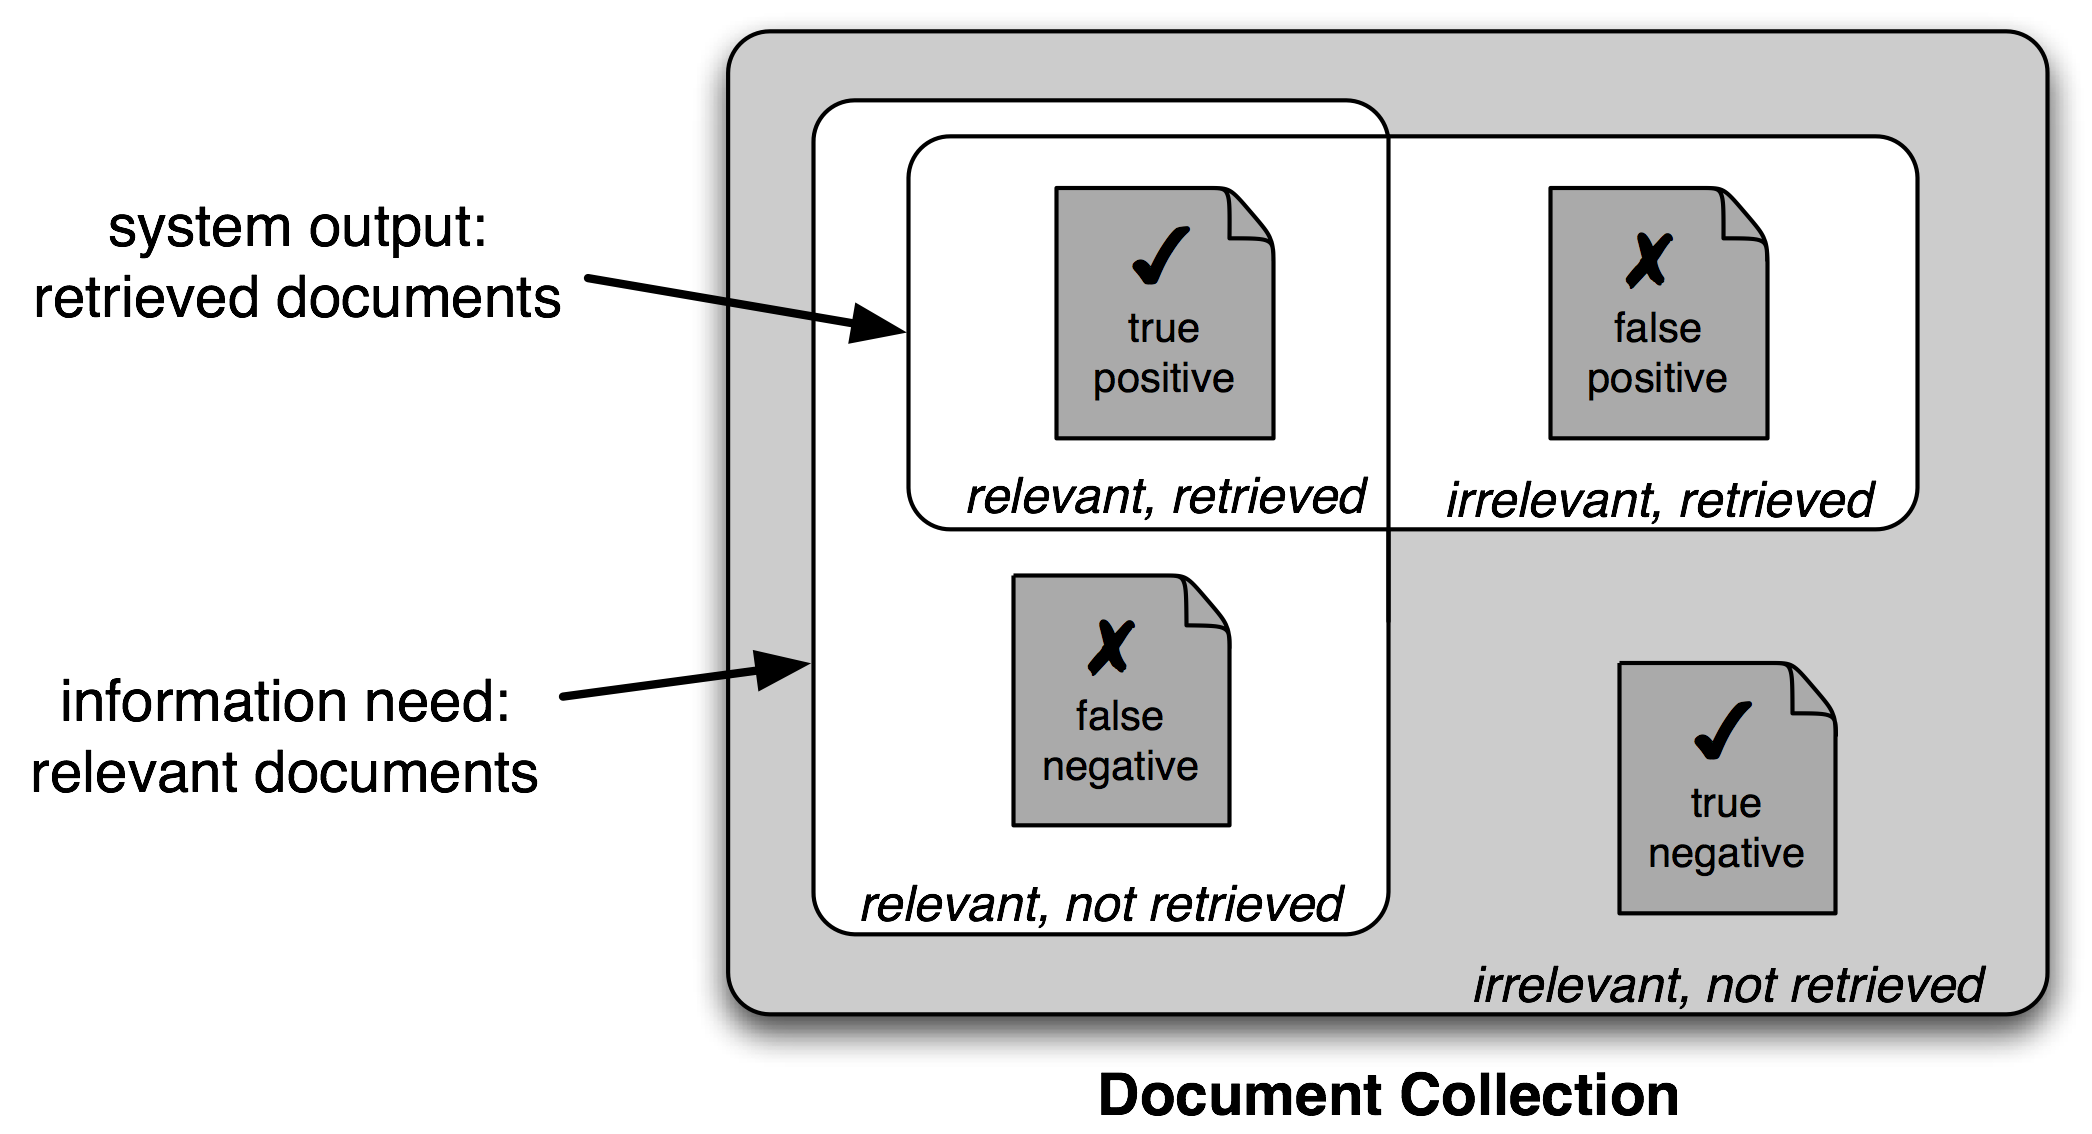

* True positives are relevant items that we correctly identified as relevant.
* True negatives are irrelevant items that we correctly identified as irrelevant.
* False positives (or Type I errors) are irrelevant items that we incorrectly identified as relevant.
* False negatives (or Type II errors) are relevant items that we incorrectly identified as irrelevant.

Given these four numbers, we can define the following metrics:

* Precision, which indicates how many of the items that we identified were relevant, is TP/(TP+FP).
* Recall, which indicates how many of the relevant items that we identified, is TP/(TP+FN).
* The F-Measure (or F-Score), which combines the precision and recall to give a single score, is defined to be the harmonic mean of the precision and recall: (2 × Precision × Recall) / (Precision + Recall).

## 3.4   Confusion Matrices

`A confusion matrix is a table where each cell [i,j] indicates how often label j was predicted when the correct label was i.`

In [78]:
 def tag_list(tagged_sents):
    return [tag for sent in tagged_sents for (word, tag) in sent]
def apply_tagger(tagger, corpus):
    return [tagger.tag(nltk.tag.untag(sent)) for sent in corpus]
gold = tag_list(brown.tagged_sents(categories='editorial'))
test = tag_list(apply_tagger(tagger, brown.tagged_sents(categories='editorial'))) # Replaced 't2' with 'tagger'
cm = nltk.ConfusionMatrix(gold, test)
print(cm.pretty_format(sort_by_count=True, show_percents=True, truncate=9))

    |                                         N                      |
    |      N      I      A      J             N             V      N |
    |      N      N      T      J      .      S      ,      B      P |
----+----------------------------------------------------------------+
 NN |  <9.4%>  0.1%   0.0%   0.6%      .   0.1%      .   0.2%   0.3% |
 IN |   0.1%  <8.3%>     .   0.0%      .   0.0%      .   0.0%   0.1% |
 AT |   0.0%   0.0%  <8.5%>     .      .      .      .   0.0%   0.0% |
 JJ |   1.2%   0.0%   0.0%  <3.3%>     .   0.0%      .   0.1%   0.2% |
  . |      .      .      .      .  <4.8%>     .      .   0.0%      . |
NNS |   0.1%   0.0%      .   0.0%   0.0%  <4.5%>     .   0.0%   0.0% |
  , |      .      .      .      .      .      .  <4.4%>     .      . |
 VB |   0.2%   0.0%   0.0%   0.1%      .      .      .  <2.7%>  0.1% |
 NP |   0.3%   0.0%   0.0%   0.1%      .   0.1%      .   0.1%  <1.9%>|
----+----------------------------------------------------------------+
(row =